In [13]:
%pip install xlrd
%pip install Jinja2

################ Load data ready for nested logit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
from stargazer.stargazer import Stargazer
import statsmodels.formula.api as smf

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



   -------------------- ------------------- 1/2 [Jinja2]
   -------------------- ------------------- 1/2 [Jinja2]
   -------------------- ------------------- 1/2 [Jinja2]
   -------------------- ------------------- 1/2 [Jinja2]
   ---------------------------------------- 2/2 [Jinja2]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
################ Load data ready for nested logit
df = pd.read_csv('model_ready.csv')
supply_df = pd.read_csv('supply_ready.csv')

# Other data
charging_df = pd.read_csv('Data Cleaning/charging_station_data.csv')
global_bev = pd.read_excel('C:/Users/Lenovo/Desktop/Dissertaion/China Data/Other/global_bev.xls')
global_phev = pd.read_excel('C:/Users/Lenovo/Desktop/Dissertaion/China Data/Other/global_phev.xls')
EV_stock = pd.read_excel("C:/Users/Lenovo/Desktop/Dissertaion/China Data/Demand/EV stock/2017-2022 EV_stock.xlsx")

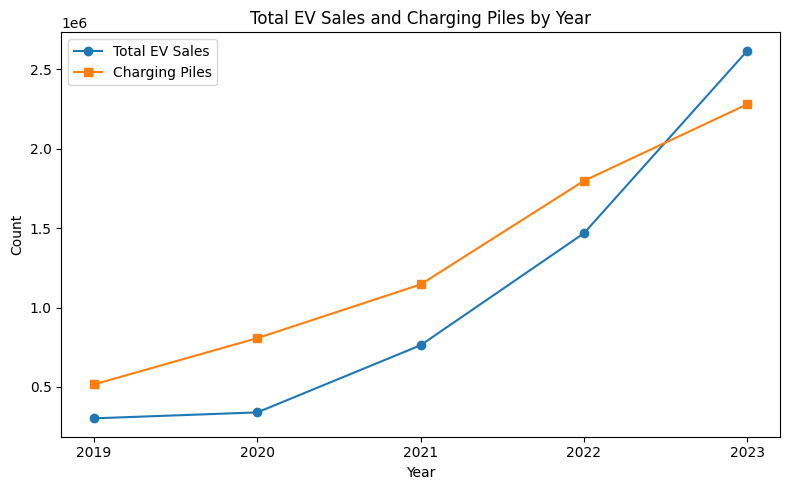

In [4]:
################ Plot sum of total EV sales and charging stations by year to compare trend

# Ensure year columns are integer type before grouping
df['year'] = df['year'].astype(int)
charging_df['year'] = charging_df['year'].astype(int)

# Group by year and sum EV sales and charging stations
ev_sales_sum = (
    df[df['fuel_type'].isin(['BEV', 'PHEV'])]
    .groupby('year')['sales']
    .sum()
)
charging_stock_sum = charging_df.groupby('year')['公共充电桩保有量（台）'].sum()

# Indices are already int, so no need to convert again

# Align years for plotting (intersection)
common_years = sorted(set(ev_sales_sum.index) & set(charging_stock_sum.index))
ev_sales_plot = ev_sales_sum.loc[common_years]
charging_stock_plot = charging_stock_sum.loc[common_years]

# Plot both on the same figure
plt.figure(figsize=(8, 5))
plt.plot(ev_sales_plot.index, ev_sales_plot.values, label='Total EV Sales', marker='o')
plt.plot(charging_stock_plot.index, charging_stock_plot.values, label='Charging Piles', marker='s')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Total EV Sales and Charging Piles by Year')
plt.legend()
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))  # Force integer ticks
plt.tight_layout()
plt.show()


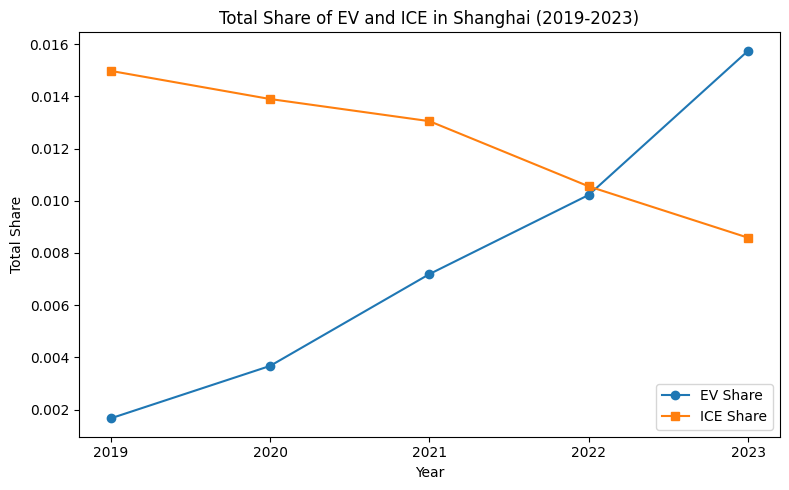

In [5]:
################ Total shares of new sales in Shanghai and trend
years = [f'P01Y{y}' for y in range(2019, 2024)]

ev_shares = []
ice_shares = []
plot_years = []

for market_id in years:
    ev_share = df.loc[(df['is_electric'] == 1) & (df['market_ids'] == market_id), 'shares'].sum()
    ice_share = df.loc[(df['is_electric'] == 0) & (df['market_ids'] == market_id), 'shares'].sum()
    ev_shares.append(ev_share)
    ice_shares.append(ice_share)
    plot_years.append(int(market_id[-4:]))

plt.figure(figsize=(8, 5))
plt.plot(plot_years, ev_shares, marker='o', label='EV Share')
plt.plot(plot_years, ice_shares, marker='s', label='ICE Share')
plt.xlabel('Year')
plt.ylabel('Total Share')
plt.title('Total Share of EV and ICE in Shanghai (2019-2023)')
plt.legend()
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


In [16]:
# Generate a descriptive statistics table of both demand and supply data set

# Select key variables for demand data descriptive statistics
demand_vars = ['shares', 'sales', 'prices', 'net_prices', 'range', 'power', 
               'battery_capacity', 'charging_stations_stock', 'EV_stock']

# Select key variables for supply data descriptive statistics  
supply_vars = ['charging_stations_stock', 'EV_stock', 'sub_fix', 'sub_ope', 
               'new_stations', 'time_trend']

# Filter dataframes to include only the selected variables that exist
demand_available_vars = [var for var in demand_vars if var in df.columns]
supply_available_vars = [var for var in supply_vars if var in supply_df.columns]

df_desc = df[demand_available_vars].copy()
supply_desc = supply_df[supply_available_vars].copy()

# Generate descriptive statistics for both datasets
demand_desc_stats = df_desc.describe()
supply_desc_stats = supply_desc.describe()

# Remove quantiles (25%, 50%, 75%) and keep only count, mean, std, min, max
stats_to_keep = ['count', 'mean', 'std', 'min', 'max']
demand_filtered = demand_desc_stats.loc[stats_to_keep]
supply_filtered = supply_desc_stats.loc[stats_to_keep]

# Add dataset identifier to column names
demand_filtered.columns = [f"Demand_{col}" for col in demand_filtered.columns]
supply_filtered.columns = [f"Supply_{col}" for col in supply_filtered.columns]

# Combine both datasets into one table
combined_stats = pd.concat([demand_filtered, supply_filtered], axis=1)

# Transpose the table (variables as rows, statistics as columns)
transposed_stats = combined_stats.T

print("="*80)
print("COMBINED AND TRANSPOSED DESCRIPTIVE STATISTICS")
print("="*80)
print(transposed_stats.round(3))

# Generate LaTeX table for the combined and transposed data
combined_latex = transposed_stats.round(3).to_latex(
    caption="Descriptive Statistics: Combined Demand and Supply Data",
    label="tab:combined_descriptive_stats",
    escape=False
)
print("\nCombined LaTeX Table:")
print(combined_latex)

# Save the combined table to file
with open('GraphsTables/combined_descriptive_stats.tex', 'w') as f:
    f.write(combined_latex)

print("\nCombined table saved to GraphsTables folder as combined_descriptive_stats.tex")

COMBINED AND TRANSPOSED DESCRIPTIVE STATISTICS
                                  count        mean         std      min  \
Demand_shares                   33545.0       0.000       0.000    0.000   
Demand_sales                    33545.0     853.968    2500.121    1.000   
Demand_prices                   33545.0      19.783      13.379    3.380   
Demand_net_prices               33545.0      17.718      12.151    1.788   
Demand_range                    33545.0     325.596     176.789   52.000   
Demand_power                    33545.0     124.323      43.346    0.852   
Demand_battery_capacity         33545.0     587.266     838.372   11.600   
Demand_charging_stations_stock  33545.0   50044.711   68287.339   18.000   
Supply_charging_stations_stock    155.0   42201.632   60769.437   18.000   
Supply_EV_stock                   155.0  295838.245  376659.567  733.000   
Supply_sub_fix                    155.0      25.742      86.516    0.000   
Supply_sub_ope                    155.0  

In [17]:
supply_df.head()

,province,year,charging_stations_stock,EV_stock,road_length,yearly_gas_price_avg,shift_share_IV,road_fuel_IV,num_models_in_market,sales_weighted_avg_range,sub_fix,sub_ope
0,Shanghai,2019,55113.0,304602,13106.0,7023.074286,3.126124e+10,9.204441e+07,123.0,329.518520,0.0,0.0
1,Shanghai,2020,85538.0,425193,13045.0,5803.269444,4.584036e+10,7.570365e+07,149.0,298.620943,0.0,0.0
2,Shanghai,2021,103249.0,665472,12917.0,7802.940278,5.800445e+10,1.007906e+08,186.0,306.336070,0.0,0.0
3,Shanghai,2022,122235.0,998341,13082.0,9194.876389,9.391351e+10,1.202874e+08,196.0,334.666560,400.0,0.0
4,Shanghai,2023,147708.0,1171415,13005.0,9157.885714,1.586627e+11,1.190983e+08,212.0,414.243129,400.0,0.0
